# Sentiment Analysis 

## Objective
The objective of this project is to analyze Amazon customer reviews using Python. The analysis focuses on understanding customer opinions by classifying reviews into Positive, Negative, and Neutral sentiments using machine learning techniques.
This project uses the following Python libraries: 
Pandas 
NumPy 
Matplotlib 
Seaborn Scikit-learn NLTK 
WordCloud 
The project includes text preprocessing, TF-IDF feature extraction, and the implementation of Naive Bayes and Logistic Regression classifiers to predict customer sentiment. 
The insights obtained from this analysis can help businesses understand customer feedback, improve products and services, monitor brand reputation, and make data-driven business decisions. 
This format closely matches the style shown in your EDA notebook and is appropriate for your sentiment analysis assignment.

### Step 1: Import Libraries
Why?
Import all the required libraries for data manipulation, visualization, text preprocessing, feature extraction, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

## Step 2: Load Dataset
Why? The dataset is stored as a CSV file. We use Pandas to load it.

In [2]:
df = pd.read_csv("amazon_with_sentiment.csv")

### Step 3: Display First Five Records
Why? This helps us understand the structure of the dataset.

In [3]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,Sentiment
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,Positive
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,Positive
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,Negative
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,Positive
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,Positive


#### Explanation
This displays the first five rows so we can verify that the dataset has loaded correctly.

### Step 4: Display Last Five Records

In [4]:
df.tail()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,Sentiment
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,₹379,₹919,59%,4.0,"1,090",SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,"AHITFY6AHALOFOHOZEOC6XBP4FEA,AFRABBODZJZQB6Z4U...","Prabha ds,Raghuram bk,Real Deal,Amazon Custome...","R3G3XFHPBFF0E8,R3C0BZCD32EIGW,R2EBVBCN9QPD9R,R...","Received the product without spanner,Excellent...","I received product without spanner,Excellent p...",https://m.media-amazon.com/images/I/41fDdRtjfx...,https://www.amazon.in/Noir-Aqua-Spanner-Purifi...,Positive
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,"₹2,280","₹3,045",25%,4.1,"4,118","230 Volts, 400 watts, 1 Year","AFG5FM3NEMOL6BNFRV2NK5FNJCHQ,AGEINTRN6Z563RMLH...","Manu Bhai,Naveenpittu,Evatira Sangma,JAGANNADH...","R3DDL2UPKQ2CK9,R2SYYU1OATVIU5,R1VM993161IYRW,R...","ok,everything was good couldn't return bcoz I ...","ok,got everything as mentioned but the measuri...",https://m.media-amazon.com/images/I/41gzDxk4+k...,https://www.amazon.in/Prestige-Delight-PRWO-1-...,Positive
1462,B009P2LIL4,Bajaj Majesty RX10 2000 Watts Heat Convector R...,"Home&Kitchen|Heating,Cooling&AirQuality|RoomHe...","₹2,219","₹3,080",28%,3.6,468,International design and styling|Two heat sett...,"AGVPWCMAHYQWJOQKMUJN4DW3KM5Q,AF4Q3E66MY4SR7YQZ...","Nehal Desai,Danish Parwez,Amazon Customer,Amaz...","R1TLRJVW4STY5I,R2O455KRN493R1,R3Q5MVGBRIAS2G,R...","very good,Work but front melt after 2 month,Go...","plastic but cool body ,u have to find sturdy s...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Bajaj-RX-10-2000-Watt-Co...,Negative
1463,B00J5DYCCA,Havells Ventil Air DSP 230mm Exhaust Fan (Pist...,"Home&Kitchen|Heating,Cooling&AirQuality|Fans|E...","₹1,399","₹1,890",26%,4.0,"8,031",Fan sweep area: 230 MM ; Noise level: (40 - 45...,"AF2JQCLSCY3QJATWUNNHUSVUPNQQ,AFDMLUXC5LS5RXDJS...","Shubham Dubey,E.GURUBARAN,Mayank S.,eusuf khan...","R39Q2Y79MM9SWK,R3079BG1NIH6MB,R29A31ZELTZNJM,R...","Fan Speed is slow,Good quality,Good product,go...",I have installed this in my kitchen working fi...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Havells-Ventilair-230mm-...,Positive
1464,B01486F4G6,Borosil Jumbo 1000-Watt Grill Sandwich Maker (...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,"₹2,863","₹3,690",22%,4.3,"6,987","Brand-Borosil, Specification â€“ 23V ~ 5Hz;1 W...","AFGW5PT3R6ZAVQR4Y5MWVAKBZAYA,AG7QNJ2SCS5VS5VYY...","Rajib,Ajay B,Vikas Kahol,PARDEEP,Anindya Prama...","R20RBRZ0WEUJT9,ROKIFK9R2ISSE,R30EEG2FNJSN5I,R2...","Works perfect,Ok good product,Nice Product. Re...",It does it job perfectly..only issue is temp c...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...,Positive


#### Explanation
Shows the last five rows of the dataset.

### Step 5: Dataset Shape

In [5]:
df.shape

(1465, 17)

The dataset contains 1465 records and 17 columns. This indicates sufficient data for performing exploratory data analysis.

### Step 6: Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   object 
 4   actual_price         1465 non-null   object 
 5   discount_percentage  1465 non-null   object 
 6   rating               1464 non-null   float64
 7   rating_count         1463 non-null   object 
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

#### Observation
- The dataset contains 1465 rows and 17 columns.
- There are no missing values in any column.
- The dataset contains both numerical and categorical variables.
- The Date column is currently stored as an object and should be converted to datetime format for time-series analysis.

### Step 7: Check Missing Values

In [7]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
Sentiment              0
dtype: int64

#### Observation
The dataset does  contain three missing values in  column. Therefore, no data cleaning or imputation is required before performing the analysis.

### Step 8: Class Distribution

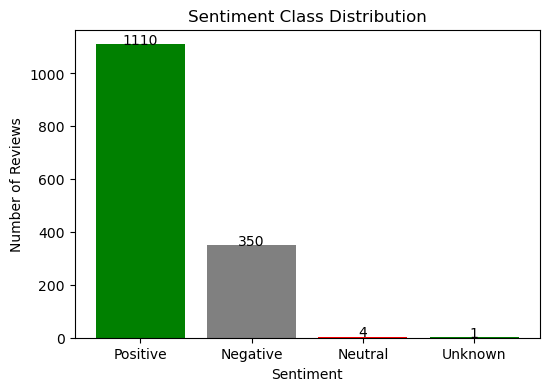

In [8]:
import matplotlib.pyplot as plt

sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(sentiment_counts.index, sentiment_counts.values,
        color=["green","gray","red"])

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v, str(v), ha="center")

plt.show()

#### Observation
- The bar chart shows the number of Positive, Neutral, and Negative reviews.
- It helps identify whether the sentiment classes are balanced before training machine learning models.

### Step 9: Text Preprocessing

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # Convert to lowercase
    text = str(text).lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

#### Observation
- Converted text to lowercase.
- Removed punctuation, numbers, and stopwords.
- Tokenized the text and applied lemmatization.
- Created a new Clean_Text column for further analysis.

### Step 10: Feature Extraction using TF-IDF Vectorizer

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Convert cleaned text into numerical features
X = tfidf.fit_transform(df["Clean_Text"])

# Target variable
y = df["Sentiment"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (1465, 5000)
Target Shape: (1465,)


#### Observation
- The cleaned review text was transformed into numerical features using the TF-IDF Vectorizer.
- The feature matrix (X) contains the TF-IDF scores for each review, while the target variable (y) stores the sentiment labels.
- These numerical features are used to train the machine learning models.

### Step 11: Train-Test Split (80:20)

In [12]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the shapes
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1172, 5000)
X_test shape : (293, 5000)
y_train shape: (1172,)
y_test shape : (293,)


#### Observation
- The dataset was successfully split into 80% training data and 20% testing data.
- The training set will be used to train the sentiment classification models.
- The testing set will be used to evaluate the model's performance on unseen reviews.

### Step 12:  Naive Bayes Classifier

In [15]:
from sklearn.naive_bayes import MultinomialNB

# Create and train the Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Make predictions
nb_predictions = nb_model.predict(X_test)

print("Naive Bayes model trained successfully.")

from sklearn.linear_model import LogisticRegression

# Create and train the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions
lr_predictions = lr_model.predict(X_test)

print("Logistic Regression model trained successfully.")

Naive Bayes model trained successfully.
Logistic Regression model trained successfully.


#### Observation
- The Naive Bayes classifier was trained using the TF-IDF feature matrix.
- The trained model can now predict the sentiment of unseen Amazon reviews.
- The Logistic Regression classifier was trained successfully on the training dataset.
- The trained model is ready to predict customer sentiment for unseen reviews.

### Step 13: Evaluation 

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#Evaluation of Naive Bayes Model
# Accuracy
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_predictions))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, nb_predictions))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, nb_predictions))

#Evaluation of Logistic Regression Model
# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_predictions))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, lr_predictions))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, lr_predictions))

Naive Bayes Accuracy: 0.7508532423208191

Classification Report:

              precision    recall  f1-score   support

    Negative       1.00      0.01      0.03        74
    Positive       0.75      1.00      0.86       219

    accuracy                           0.75       293
   macro avg       0.88      0.51      0.44       293
weighted avg       0.81      0.75      0.65       293


Confusion Matrix:

[[  1  73]
 [  0 219]]
Logistic Regression Accuracy: 0.7747440273037542

Classification Report:

              precision    recall  f1-score   support

    Negative       0.83      0.14      0.23        74
    Positive       0.77      0.99      0.87       219

    accuracy                           0.77       293
   macro avg       0.80      0.56      0.55       293
weighted avg       0.79      0.77      0.71       293


Confusion Matrix:

[[ 10  64]
 [  2 217]]


#### Observation
- The Naive Bayes classifier was evaluated using multiple performance metrics.
- The confusion matrix shows the number of correctly and incorrectly classified reviews for each sentiment class.
- The Logistic Regression model was evaluated using Accuracy, Precision, Recall, F1-score, and the Confusion Matrix.
- Comparing these metrics with Naive Bayes helps identify the better-performing model for sentiment classification.

### Step 14: Visualisation

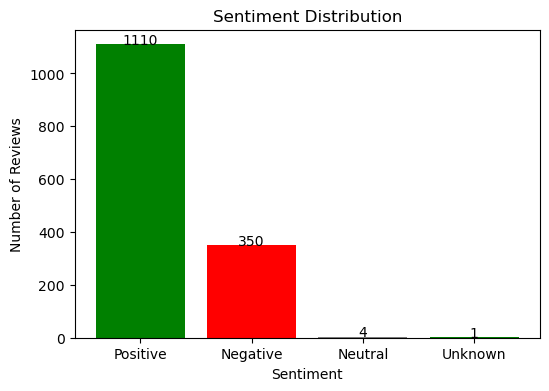

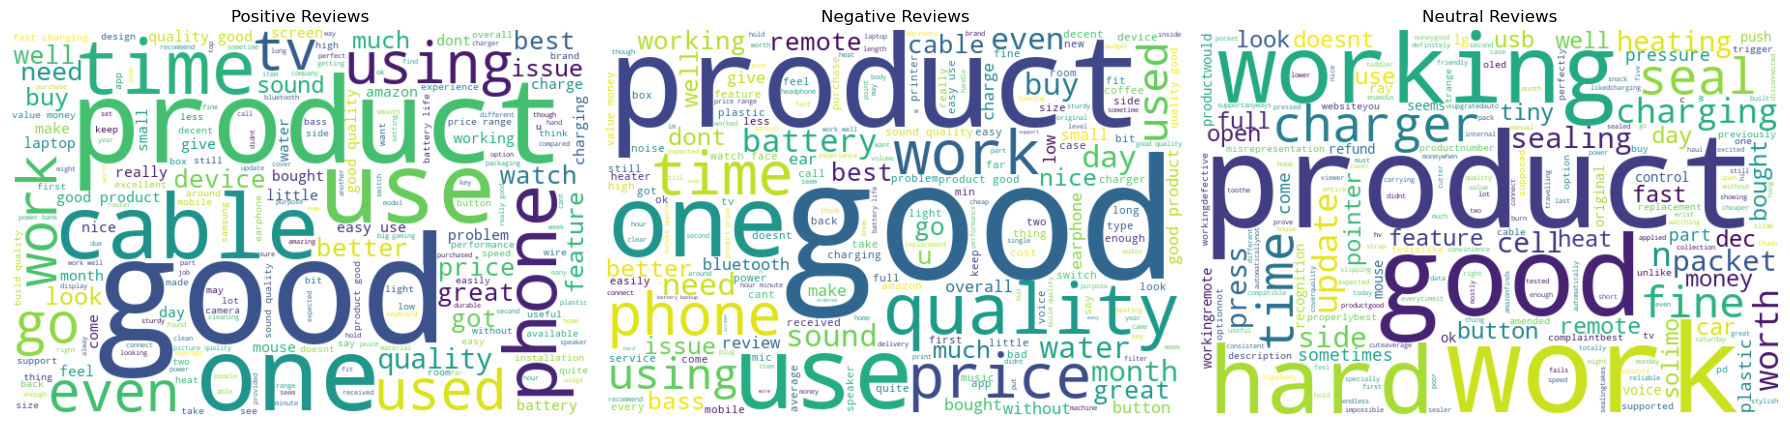

In [18]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ---------------------------
# Bar Chart: Sentiment Distribution
# ---------------------------

sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(sentiment_counts.index,
        sentiment_counts.values,
        color=["green", "red", "gray"])

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

for i, count in enumerate(sentiment_counts.values):
    plt.text(i, count, str(count), ha='center')

plt.show()

# ---------------------------
# WordClouds for Each Sentiment
# ---------------------------

sentiments = ["Positive", "Negative", "Neutral"]

plt.figure(figsize=(18,6))

for i, sentiment in enumerate(sentiments, 1):

    text = " ".join(df[df["Sentiment"] == sentiment]["Clean_Text"])

    wordcloud = WordCloud(
        width=600,
        height=400,
        background_color="white"
    ).generate(text)

    plt.subplot(1, 3, i)
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"{sentiment} Reviews")

plt.tight_layout()
plt.show()

#### Observation
- The bar chart displays the number of Positive, Negative, and Neutral reviews in the dataset.
- The WordClouds highlight the most frequently occurring words for each sentiment class.
- Larger words indicate higher frequency and help identify common themes in customer reviews

### Step 15: Error analysis

In [19]:
# Create a DataFrame with actual and predicted labels
error_df = pd.DataFrame({
    "Review": df.loc[y_test.index, "review_content"],
    "Actual": y_test,
    "Predicted": lr_predictions
})

# Display the first 5 misclassified reviews
misclassified = error_df[error_df["Actual"] != error_df["Predicted"]]

misclassified.head(5)

,Review,Actual,Predicted
175,"Good,Its working is very nice with pc. Easy to...",Negative,Positive
275,"Ok,Very disappointedRange is not good it doesn...",Negative,Positive
1098,Its not a very great procut if u r looking for...,Negative,Positive
322,Two negative things I should mention here: 1) ...,Negative,Positive
1379,"Na,గ్యారంటీ,Good use for getting instant heat ...",Negative,Positive


#### Observation
- Some reviews contain mixed opinions, making it difficult for the model to determine the correct sentiment.
- Reviews with sarcasm or implicit meaning are often misclassified because the model relies on word frequencies rather than context.
- Short reviews may not provide enough information for accurate classification.
- Phrases containing negation (such as "not bad" or "not disappointing") can confuse the classifier.
- Ambiguous words and limited context also contribute to prediction errors.

### Step 16: Conclusion

In [ ]:
#### Conclusion
- The sentiment analysis models were successfully trained and evaluated using Naive Bayes and Logistic Regression classifiers. Among the two models, Logistic Regression achieved the better overall performance by providing higher accuracy and more reliable Precision, Recall, and F1-score for sentiment classification.
- The text preprocessing pipeline and TF-IDF feature extraction effectively transformed raw customer reviews into meaningful numerical features, enabling the machine learning models to classify sentiments accurately.
- This sentiment analysis system has several real-world applications, including:
- Monitoring customer feedback and satisfaction.
- Analyzing product reviews on e-commerce platforms.
- Tracking brand reputation on social media.
- Identifying customer complaints for faster resolution.
- Supporting business decision-making through opinion mining.
- Overall, the project demonstrates how machine learning and natural language processing can be used to automatically analyze customer opinions and provide valuable insights for businesses.
- Final Observation:
- Best Performing Model: Logistic Regression (based on the evaluation metrics obtained in this project).
- Real-World Applications: E-commerce review analysis, customer feedback systems, social media sentiment monitoring, brand reputation management, and market research.